# Clasificación con redes neuronales

En este notebook simple usaremos una FCNN (completamente conectada) para resolver el problema de clasificación de ID de partículas, visto previamente para SVMs.

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.utils import shuffle

In [12]:
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 150)

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14)
matplotlib.rc('ytick', labelsize=14)
matplotlib.rcParams['figure.dpi'] = 300

### Librerías para Deep Learning

[Tensorflow](https://www.tensorflow.org/?hl=es-419) es una biblioteca de uso muy común para el desarrollo de modelos de aprendizaje profundo. Es una plataforma de código abierto desarrollada por Google. Admite programación en varios lenguajes, como C++, Java, Python, y muchos otros.

[Keras](https://keras.io/) es una API de alto nivel (Application Programming Interface) construida sobre TensorFlow (o Theano, otra biblioteca de aprendizaje profundo). Es específica para Python, y podemos pensar en ella como el equivalente de la biblioteca sklearn, pero para redes neuronales. Es menos general y menos personalizable, pero muy fácil de usar y comparativamente más sencilla que TensorFlow.

[PyTorch](https://pytorch.org/) es otra biblioteca muy popular para el desarrollo de modelos de aprendizaje profundo, desarrollada por Meta (Facebook). A diferencia de Keras, no es una API de alto nivel sobre otra biblioteca, sino un framework completo en sí mismo. Es especialmente popular en investigación por su flexibilidad para construir arquitecturas no estándar, aunque eso viene con una curva de aprendizaje más pronunciada y bastante más código para tareas simples.

En este curso usaremos Keras con TensorFlow como back-end, porque para los problemas que veremos su simplicidad tiene más peso que la flexibilidad extra de PyTorch.

**Comparación**

| | TensorFlow | Keras | PyTorch |
|---|---|---|---|
| **Qué es** | Framework completo | API de alto nivel (sobre TensorFlow) | Framework completo |
| **Desarrollado por** | Google | Ahora integrado a TensorFlow | Meta (Facebook) |
| **Curva de aprendizaje** | Media-alta | Baja | Media-alta |
| **Líneas de código para un modelo simple** | Muchas | Pocas | Muchas |
| **Flexibilidad para arquitecturas no estándar** | Alta | Media | Muy alta |
| **Dónde se usa más** | Producción, industria | Prototipado rápido, docencia | Investigación, papers recientes |


In [13]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [14]:
#!pip install tensorflow

In [15]:
import tensorflow as tf

In [16]:
tf.__version__

'2.20.0'

Importamos `keras` y usaremos `Sequential`, que admite una entrada y una salida

In [17]:
import keras

from keras.models import Sequential # El modelo se construye agregando una capa después de otra

from keras.layers import Dense #totalmente conectadas: cada output se conecta con cada input

from keras.layers import Dropout #para regularización

Comenzamos con el problema de 4top vs ttbar, y utilizamos la configuración en la que añadimos las características "número de leptones", "número de jets", etc. Como referencia, el SVM óptimo alcanzó un 94-95% de precisión. Cabe destacar que esos números no se obtuvieron utilizando validación cruzada anidada, por lo que podrían ser ligeramente optimistas.

In [18]:
X = pd.read_csv('Features_lim_2.csv')

In [19]:
y = np.genfromtxt('Labels_lim_2.txt')

In [20]:
X.values.shape

(5000, 24)

In [21]:
X.head()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
0,0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800,5,1,3,0,1
1,1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630,4,0,2,0,2
2,2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690,5,1,4,0,0
3,3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631,5,1,4,0,0
4,4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381,5,0,5,0,0


In [22]:
y

array([0., 0., 0., ..., 0., 1., 0.])

Aquí no hay un proceso de validación cruzada "integrado", por lo que tendríamos que implementarlo nosotros mismos. Por ahora, podemos construir tres conjuntos: entrenamiento, validación (para la optimización de parámetros) y prueba (para la evaluación final). Idealmente, deberíamos estructurarlo como una validación cruzada.

En la práctica, rara vez se hace CV k-fold completa con redes neuronales. Cada fold implica reentrenar la red desde cero, así que el costo computacional escala rápido: con 5 folds ya estamos pagando 5 veces el costo de entrenamiento, y eso antes de siquiera empezar a buscar hiperparámetros. Además, la razón principal para usar CV es obtener una estimación confiable del desempeño cuando el dataset es chico; con datasets grandes (el escenario típico donde las NN funcionan mejor), un solo split bien hecho ya da una estimación razonablemente estable.

Por eso optamos por un split fijo train/validación/prueba, y usamos el set de validación para *early stopping* y ajuste de hiperparámetros. Esto evita el costo de CV sin sacrificar demasiado rigor.

#### Sets de entrenamiento y prueba

Este dataset tiene un desbalance importante entre las dos clases. Para que esa proporción se mantenga en cada split, usamos `stratify` al dividir los datos.

In [23]:
clase, total = np.unique(y, return_counts=True)
print(dict(zip(clase, total)))

{np.float64(0.0): np.int64(4189), np.float64(1.0): np.int64(811)}


In [24]:
razon = total[1] / total[0]
print(f"Razón: {razon:.2f}")

Razón: 0.19


In [25]:
# Primero separamos test (20%), estratificado por clase
X_temp, X_test, y_temp, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=10
)

# Del resto, separamos train/val (80/20 de lo que queda)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=10
)

print(X_train.shape, X_val.shape, X_test.shape)
print("Balance train:", y_train.mean(), "| val:", y_val.mean(), "| test:", y_test.mean())

(3200, 24) (800, 24) (1000, 24)
Balance train: 0.1621875 | val: 0.1625 | test: 0.162


### Construyendo la red

Pensemos en la arquitectura del modelo.

Nuestra capa de entrada tiene **24 neuronas** (24 características)

Nuestra capa de salida tiene **una neurona** (la salida es la probabilidad de que el objeto pertenezca a la clase positiva). También podríamos configurarla con dos neuronas (y usar softmax como la no linealidad final), pero esto es redundante en un problema de clasificación binaria. La neurona de salida será una función **sigmoide**

Añadiremos **dos capas ocultas**. En este caso, ambas tienen tamaño = 20 (debemos optimizar este hiperparámetro!). También podemos reservar la posibilidad de añadir una capa de dropout después de cada una.

Otras decisiones que debemos tomar son: qué no linealidades usar (por ahora: ReLU para las capas ocultas, sigmoide para la final), qué optimizador usar (Adam), qué tasa de aprendizaje inicial adoptar (aquí 0.001, aunque nuevamente esto debería decidirse mediante CV), el número de épocas (por ejemplo, 100; podemos graficar cantidades de interés para verificar que esto sea suficiente), el tamaño de lote (batch size) para el paso de descenso por gradiente (aquí 200, pero podemos explorarlo!) y la función de pérdida. Esta última es la entropía cruzada binaria ([binary cross entropy](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a)), que es la elección estándar para problemas de clasificación donde la salida es una probabilidad. Premia la "confianza" en una predicción correcta (alta probabilidad).

El siguiente comando nos ayuda a explorar todas las posibles opciones

In [26]:
dir(keras.optimizers)

['Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'Ftrl',
 'Lamb',
 'Lion',
 'LossScaleOptimizer',
 'Muon',
 'Nadam',
 'Optimizer',
 'RMSprop',
 'SGD',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'deserialize',
 'get',
 'legacy',
 'schedules',
 'serialize']

In [27]:
dir(keras.losses)

['BinaryCrossentropy',
 'BinaryFocalCrossentropy',
 'CTC',
 'CategoricalCrossentropy',
 'CategoricalFocalCrossentropy',
 'CategoricalGeneralizedCrossEntropy',
 'CategoricalHinge',
 'Circle',
 'CosineSimilarity',
 'Dice',
 'Hinge',
 'Huber',
 'KLDivergence',
 'LogCosh',
 'Loss',
 'MeanAbsoluteError',
 'MeanAbsolutePercentageError',
 'MeanSquaredError',
 'MeanSquaredLogarithmicError',
 'Poisson',
 'SparseCategoricalCrossentropy',
 'SquaredHinge',
 'Tversky',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'binary_crossentropy',
 'binary_focal_crossentropy',
 'categorical_crossentropy',
 'categorical_focal_crossentropy',
 'categorical_generalized_cross_entropy',
 'categorical_hinge',
 'circle',
 'cosine_similarity',
 'ctc',
 'deserialize',
 'dice',
 'get',
 'hinge',
 'huber',
 'kl_divergence',
 'log_cosh',
 'mean_absolute_error',
 'mean_absolute_percentage_error',
 'mean_squared_error',
 'mean_squared_logarith

La opción estándar para un caso como el nuestro, donde las etiquetas son 0/1, pero podemos predecir una probabilidad, es binary cross-entropy or log loss:

L = - $\frac{1}{N} \sum_{i=1}^N y_i \cdot log(p(y_i)) + (1-y_i) \cdot log (1 - p(y_i))$

$p$ es la probabilidad de que un objeto pertenezca a la clase positiva. Penaliza los ejemplos positivos que están asociados con una probabilidad predicha baja, y los ejemplos negativos que están asociados con una probabilidad predicha alta.


Acá una lista de funciones de activación

In [28]:
dir(keras.activations)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparse_sigmoid',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

### Así es como construímos la red completamente conectada en Keras

In [29]:
model = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model.add(Dense(20, activation='relu', input_shape=(24,)))

# Agrega una  segunda capa oculta y especificamos el tamaño

model.add(Dense(20, activation='relu'))

# Agrega capa de salida

model.add(Dense(1, activation='sigmoid'))

model.summary() # resumen de la arquitectura



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

In [31]:
mynet = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.1691 - loss: 42510.7109 - val_accuracy: 0.2188 - val_loss: 20985.0957
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3709 - loss: 12888.0527 - val_accuracy: 0.5400 - val_loss: 5789.7861
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6541 - loss: 6149.9658 - val_accuracy: 0.7375 - val_loss: 3859.9312
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7325 - loss: 4588.3198 - val_accuracy: 0.7038 - val_loss: 2959.2185
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6775 - loss: 3629.7876 - val_accuracy: 0.6600 - val_loss: 2564.7678
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6591 - loss: 3075.4744 - val_accuracy: 0.6675 - val_loss: 2277.1675
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6659 - loss: 2549.4570 - val_accuracy: 0.6600 - val_loss: 1911.9781
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.

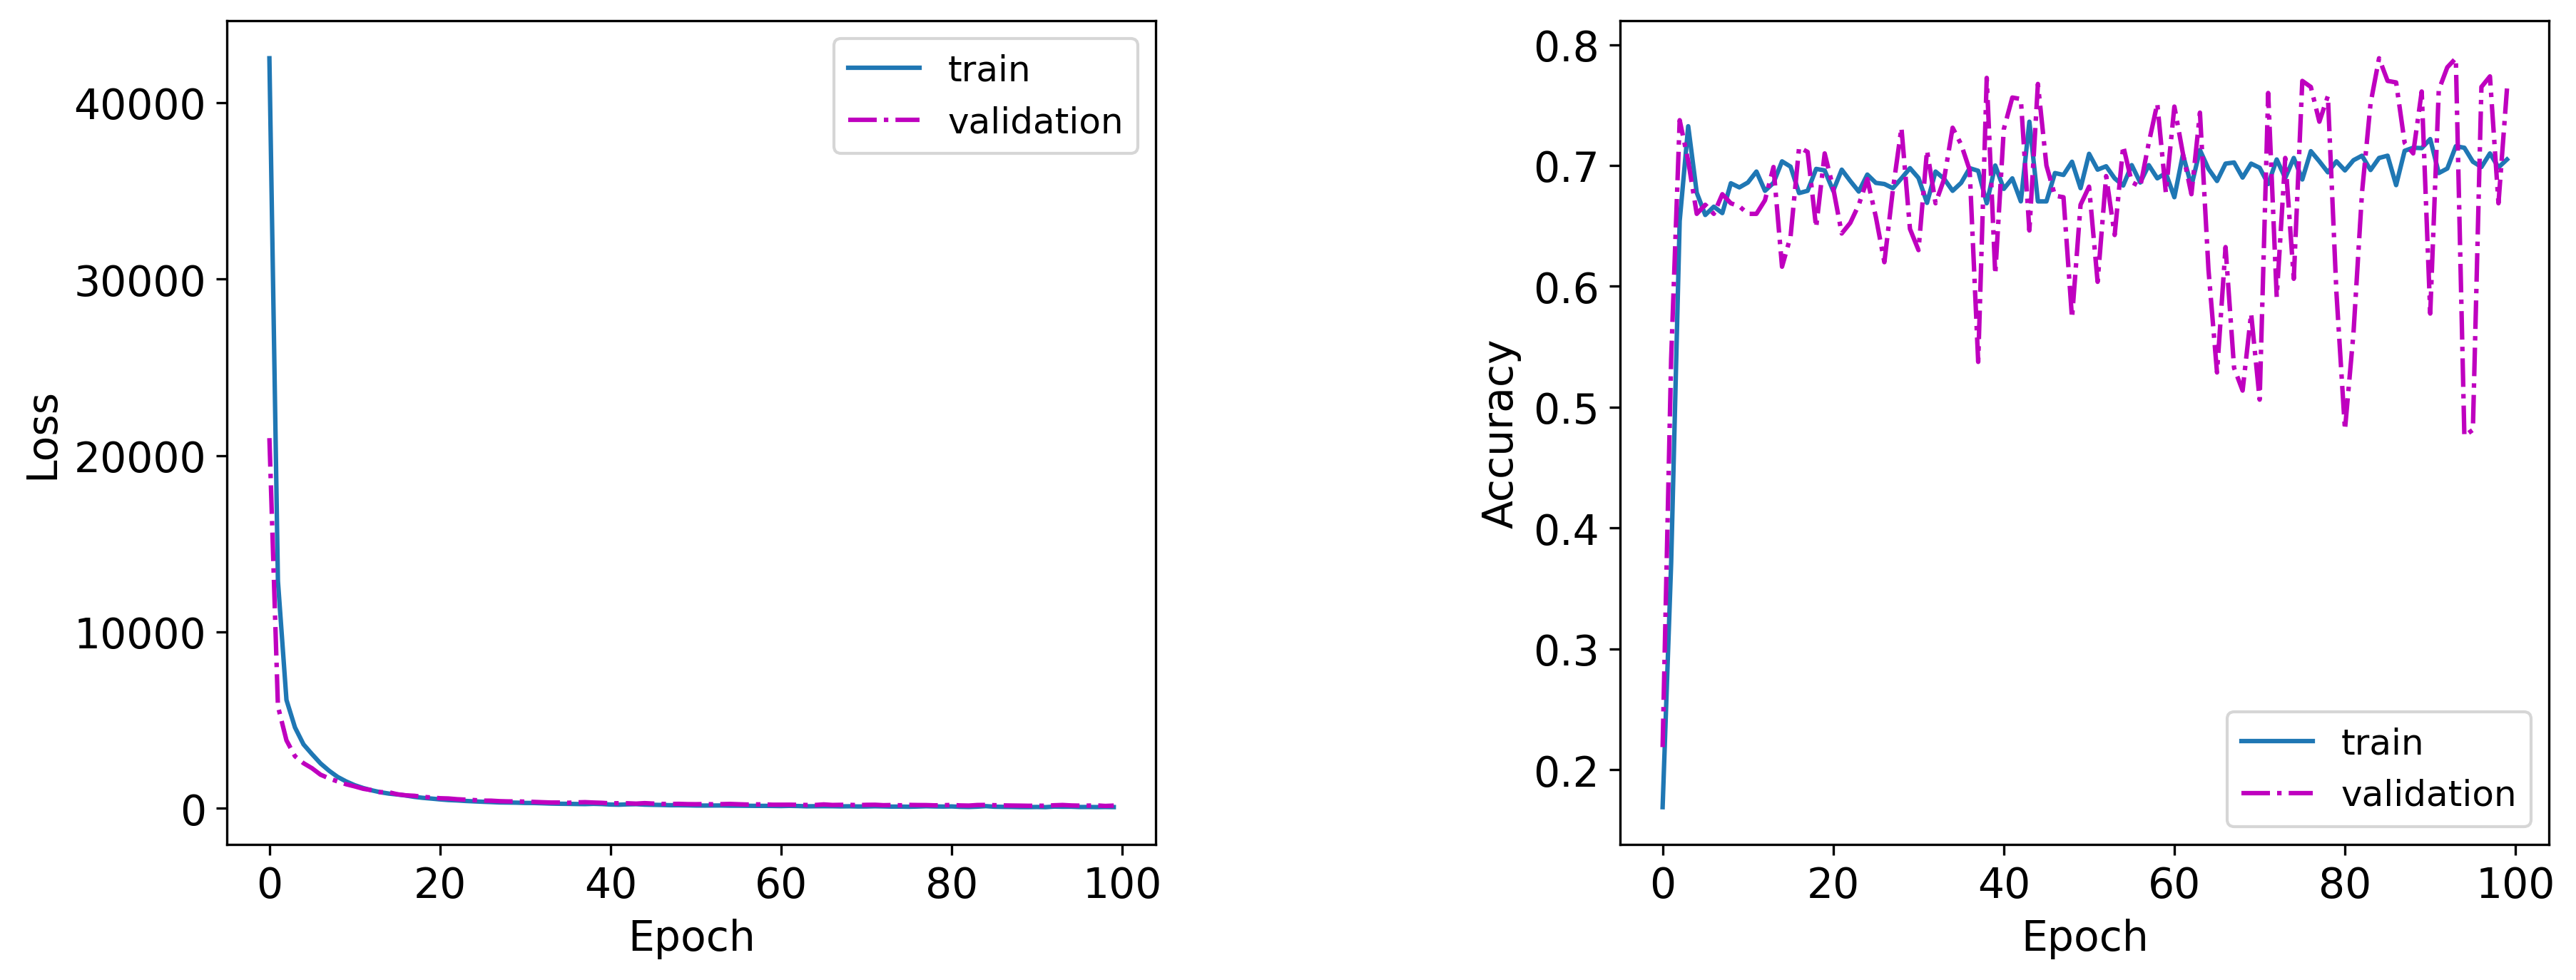

In [32]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet.history['accuracy'], label = 'train')
plt.plot(mynet.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

Con el keyword `métrica` podemos cambiar a la métrica que queremos ver. El valor absoluto de la pérdida no se traduce directamente en algo intuitivo (a diferencia de accuracy, que sí es un % de aciertos), aunque sigue siendo muy útil para comparar train vs. validación y detectar overfitting.

### Ahora pruebe usted

Usando el mismo código de arriba como plantilla, modifíquelo para responder:

**¿Qué pasa si agrega una tercera capa oculta?** Agréguela (por ejemplo, de tamaño 20 también) y comenten: ¿por qué una arquitectura más profunda podría ayudar o no ayudar en este problema?

**¿Qué pasa si cambia el tamaño de las capas ocultas** (por ejemplo, de 20 a 5, o de 20 a 100)? Antes de correrlo: ¿espera que la red sea más lenta o más rápida de entrenar? ¿Más o menos propensa a sobreajustar?

**¿Qué pasa si usa otra función de activación** en las capas ocultas (por ejemplo `tanh` en vez de `relu`)? Revise la lista de activaciones disponibles que exploramos arriba con `dir(keras.activations)`.

No hace falta entrenar todavía, solo construyan el modelo con `model.summary()` al final y observe cómo cambia el número de parámetros totales según sus decisiones.


In [ ]:
# Variante 1: agregamos una tercera capa oculta
model_v1 = Sequential()
model_v1.add(Dense(20, activation='relu', input_shape=(24,)))
model_v1.add(Dense(20, activation='relu'))
model_v1.add(Dense(20, activation='relu'))
model_v1.add(Dense(1, activation='sigmoid'))
model_v1.summary()

# Variante 2a: capas chicas (5 neuronas)
model_v2a = Sequential()
model_v2a.add(Dense(5, activation='relu', input_shape=(24,)))
model_v2a.add(Dense(5, activation='relu'))
model_v2a.add(Dense(1, activation='sigmoid'))
model_v2a.summary()

# Variante 2b: capas grandes (100 neuronas)
model_v2b = Sequential()
model_v2b.add(Dense(100, activation='relu', input_shape=(24,)))
model_v2b.add(Dense(100, activation='relu'))
model_v2b.add(Dense(1, activation='sigmoid'))
model_v2b.summary()

# Variante 3: activación tanh en vez de relu
model_v3 = Sequential()
model_v3.add(Dense(20, activation='tanh', input_shape=(24,)))
model_v3.add(Dense(20, activation='tanh'))
model_v3.add(Dense(1, activation='sigmoid'))
model_v3.summary()


Variante 1 (3 capas ocultas, 20-20-20): 1,361 parámetros
Variante 2a (2 capas de 5): 161 parámetros
Variante 2b (2 capas de 100): 12,701 parámetros
Variante 3 (2 capas de 20, tanh): 941 parámetros (igual al baseline, tanh no cambia el conteo)


**Respuesta:**

- Más capas o capas más grandes = más parámetros (161 → 941 → 1,361 → 12,701). Una tercera capa oculta *podría* ayudar si el problema tuviera relaciones más complejas y jerárquicas, pero con solo 24 features tabulares probablemente no aporta mucho y sí aumenta el riesgo de sobreajuste.
- Capas de 5 neuronas: entrena más rápido (menos parámetros, ~161) y con menos riesgo de sobreajuste, pero puede quedarse corta en capacidad. Capas de 100: mucho más lenta (12,701 parámetros, ~13x el baseline) y mucho más propensa a sobreajustar en un dataset de solo 3,200 ejemplos de entrenamiento.
- `tanh` no cambia el número de parámetros (misma arquitectura), pero al saturar en ±1 puede ayudar a estabilizar el entrenamiento cuando los datos no están escalados (spoiler: por eso el ejemplo de abajo con tanh mejora un poco respecto al puramente relu, aunque el problema real sigue siendo la falta de escalado).

### Listos para ajustar!

Nota también los hiperparámetros adicionales "epochs" (el número de pasadas completas de ida y vuelta sobre el conjunto de datos) y "batch size" (cuántos datos se utilizan en cada paso para actualizar los pesos).

### Antes de correr esto

¿Qué accuracy espera que logre esta red? Como referencia, el SVM óptimo llegó a 94-95%. Escriba su predicción antes de correr la celda de abajo.

> Mi predicción de accuracy: 96-97%

Accuracy para entrenamiento y validación no se ven muy bien

In [57]:
model = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model.add(Dense(20, activation='relu', input_shape=(24,)))

# Agrega una  segunda capa oculta y especificamos el tamaño

model.add(Dense(20, activation='relu'))

# Otra capa oculta (correctly placed before the output layer)
model.add(Dense(20, activation='tanh'))

# Agrega capa de salida

model.add(Dense(1, activation='sigmoid'))

model.summary() # resumen de la arquitectura

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361 (5.32 KB)

 Trainable params: 1,361 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

Grafiquemos cómo se ve esto en cada época

In [58]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

In [59]:
mynet = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.1637 - loss: 1.9511 - val_accuracy: 0.1750 - val_loss: 1.7365
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1872 - loss: 1.6107 - val_accuracy: 0.2000 - val_loss: 1.4791
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2125 - loss: 1.3224 - val_accuracy: 0.2725 - val_loss: 1.1353
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3369 - loss: 1.0219 - val_accuracy: 0.3275 - val_loss: 0.9161
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4728 - loss: 0.7870 - val_accuracy: 0.6087 - val_loss: 0.6911
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6084 - loss: 0.6491 - val_accuracy: 0.6413 - val_loss: 0.6092
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6575 - loss: 0.5887 - val_accuracy: 0.7900 - val_loss: 0.5615
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8003 - loss: 0.5470 - val_accuracy: 0.7887 

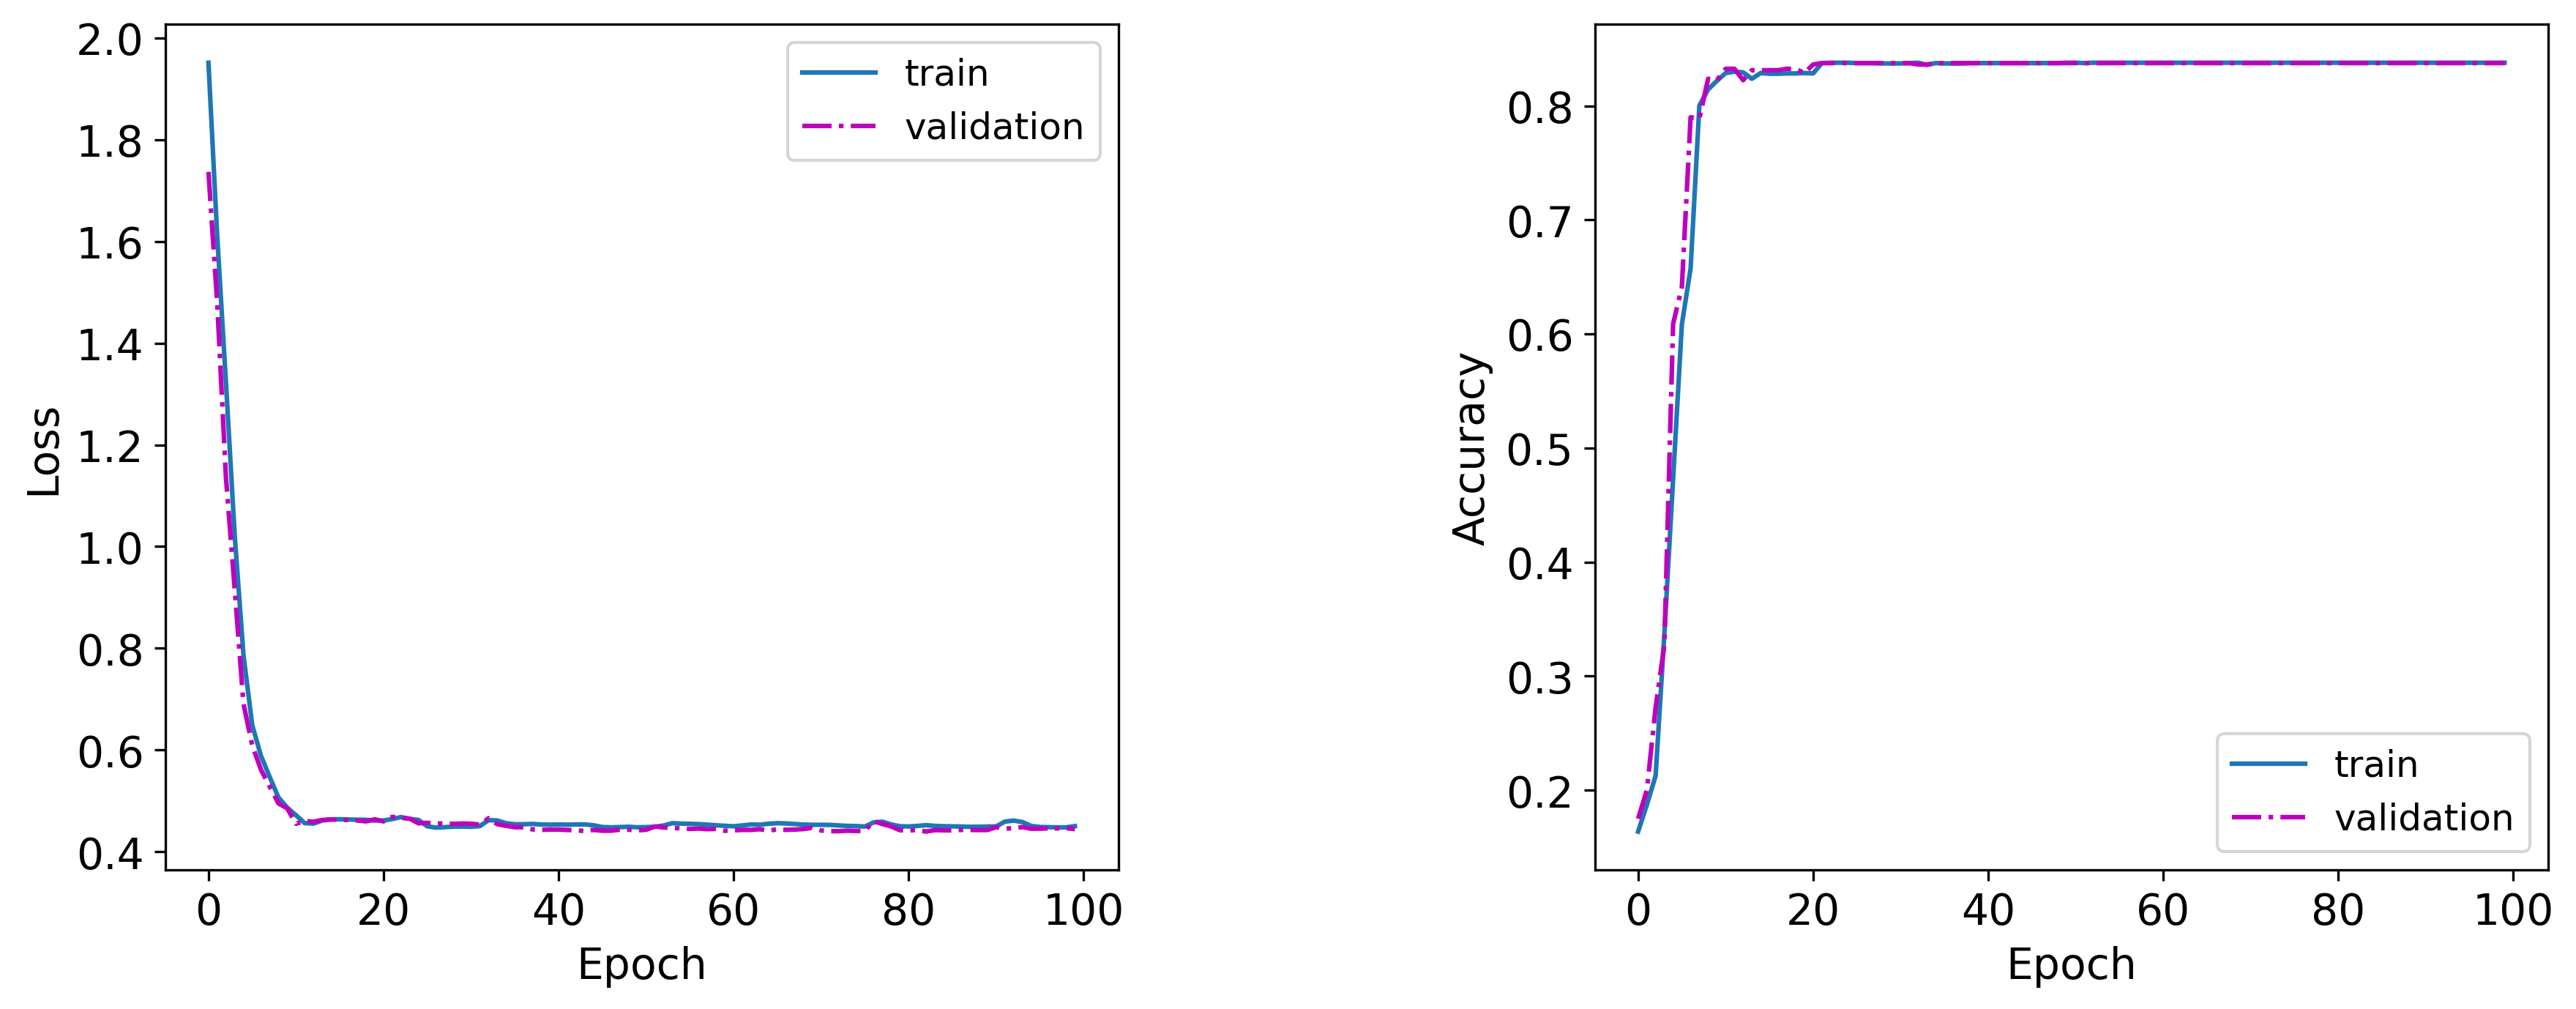

In [60]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet.history['accuracy'], label = 'train')
plt.plot(mynet.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

La métrica mejoró bastate, y se ajusta bastante bien a los datos.

### Diagnóstico

El accuracy salió mucho peor de lo esperado. Antes de seguir:

1. Corra `X.describe()` en la celda de abajo y miren los rangos (min, max, mean) de las distintas columnas.
2. ¿Ve algo que podría estar afectando el entrenamiento por gradiente descendiente?
3. Le parece que la curva de la pérdida es suficiente para el diagnóstico del modelo?

In [37]:
X.describe()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2499.500000,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704,6.245400,1.418200,4.49240,0.030400,0.304400
std,1443.520003,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070,2.157709,0.955767,2.03479,0.171702,0.519418
min,0.000000,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130,1.000000,0.000000,0.00000,0.000000,0.000000
25%,1249.750000,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080,5.000000,1.000000,3.00000,0.000000,0.000000
50%,2499.500000,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000,6.000000,1.000000,4.00000,0.000000,0.000000
75%,3749.250000,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765,7.000000,2.000000,6.00000,0.000000,1.000000
max,4999.000000,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660,13.000000,6.000000,13.00000,1.000000,3.000000


**Respuesta:**

Sí: las columnas están en escalas completamente distintas. `MET`, `P1`...`P16` tienen valores del orden de 10⁴-10⁵, mientras que `METphi` va de -π a π y `Total_products`/`Total_leptons` son enteros chicos (0-5). Para gradiente descendiente esto es un problema: el gradiente respecto a las features grandes domina la actualización de pesos, la superficie de pérdida queda muy "estirada" en algunas direcciones, y el optimizador oscila o converge mal (se ve en los valores de loss, que llegan a estar en el orden de cientos).

La curva de pérdida por sí sola no basta para diagnosticar esto: los valores absolutos del loss no dicen nada sobre su causa. Hay que cruzarla con `X.describe()` (o simplemente saber que faltó escalar) para entender *por qué* el entrenamiento se ve mal.

### Nos olvidamos de escalar (por qué es necesario??)

In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
scaler = StandardScaler()

Escalamos sólo los datos del set entrenamiento (para evitar leakage)

In [40]:
scaler.fit(X_train)

StandardScaler()

In [41]:
Xst_train = scaler.transform(X_train)
Xst_val = scaler.transform(X_val)
Xst_test = scaler.transform(X_test)

### Reentrenamos la red

In [42]:
model_st = Sequential()
model_st.add(Dense(20, activation='relu', input_shape=(24,)))
model_st.add(Dense(20, activation='relu'))
model_st.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_st.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_st = model_st.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0) #verbose=0 para no mostrar el resultado en cada epoca

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


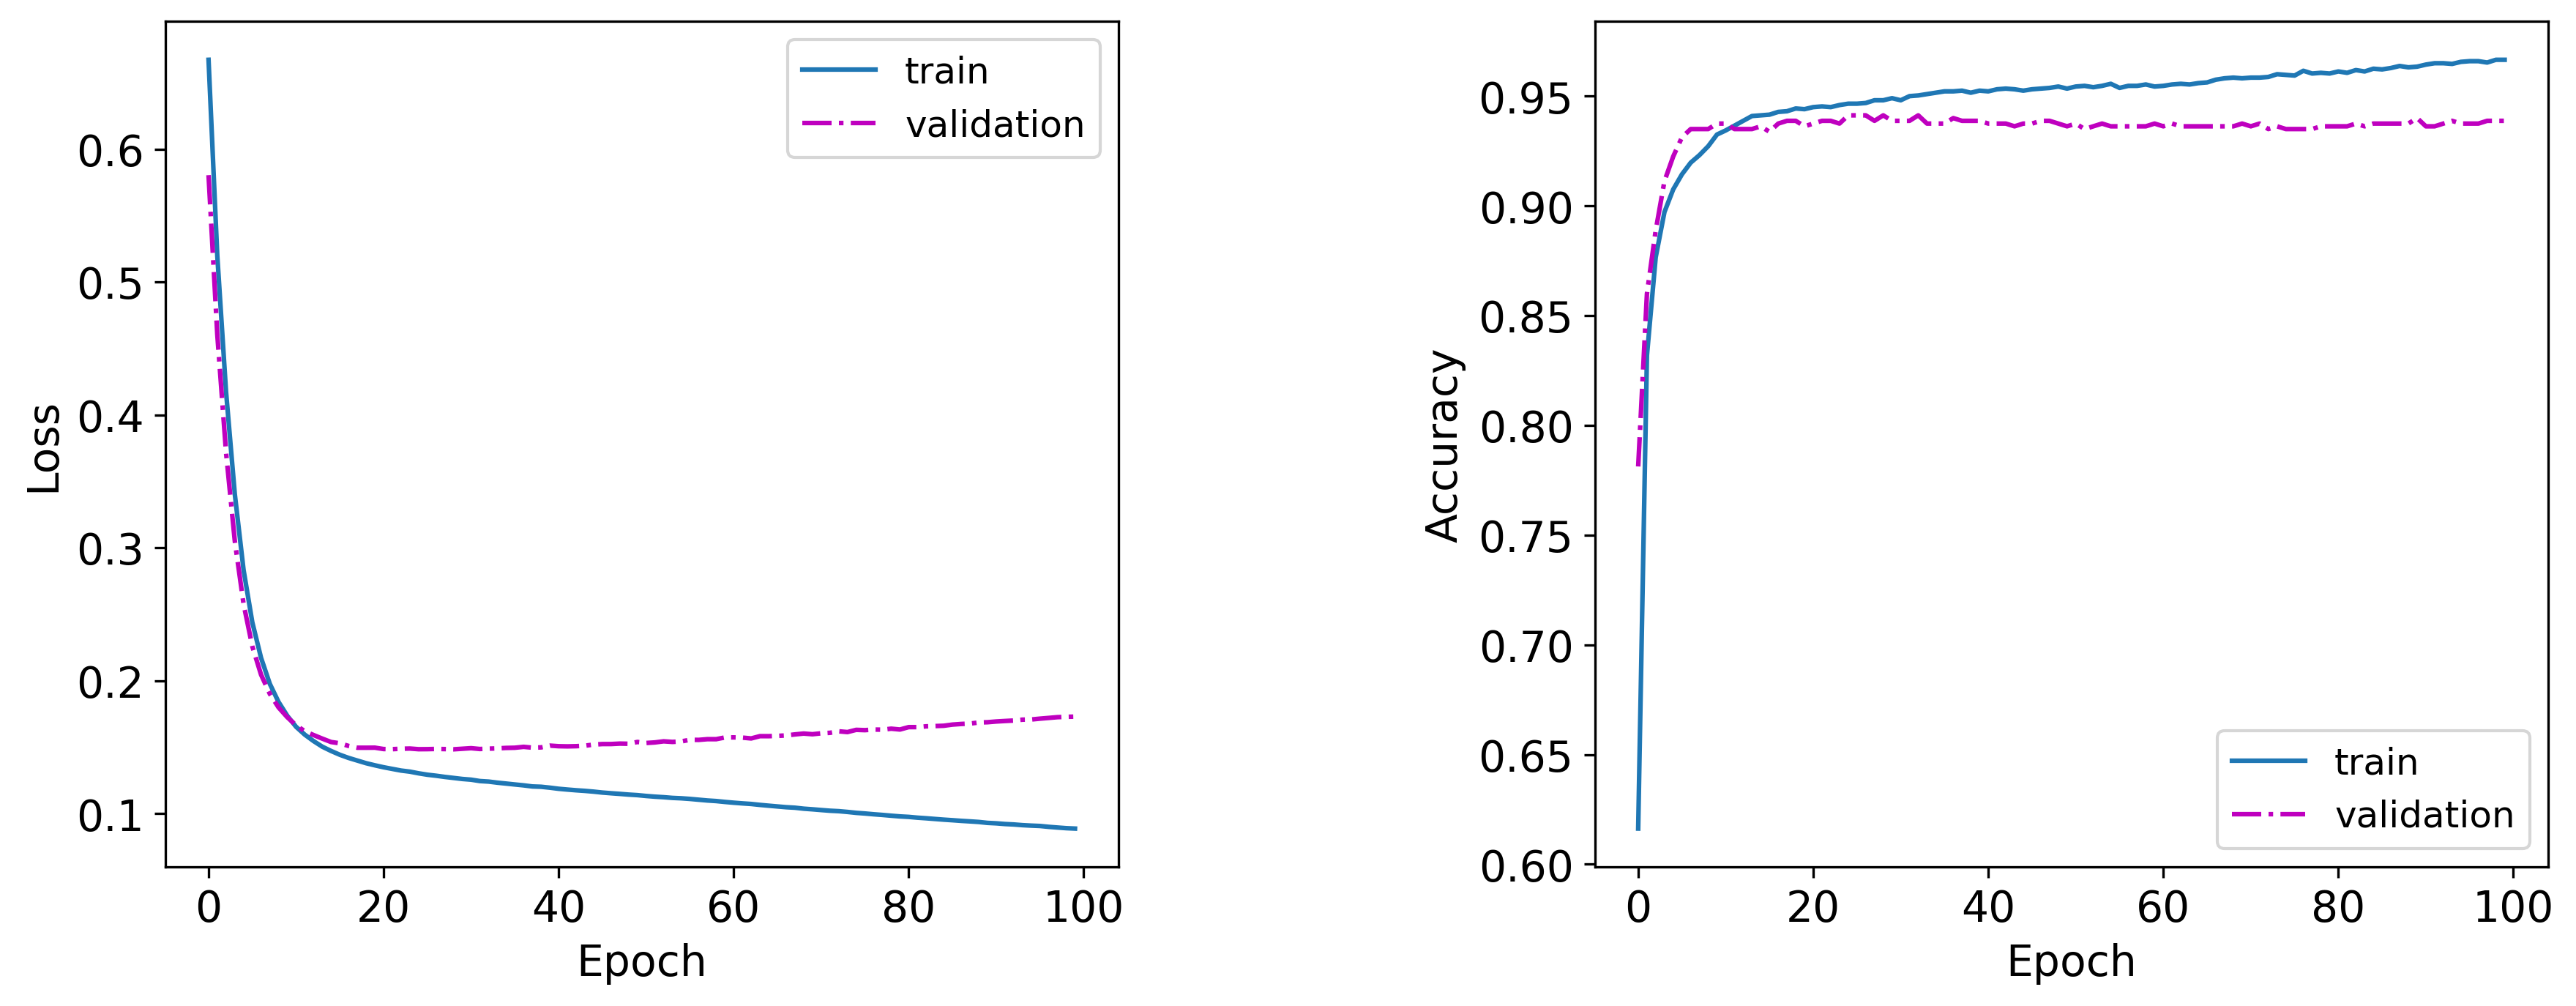

In [43]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_st.history['loss'], label = 'train')
plt.plot(mynet_st.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_st.history['accuracy'], label = 'train')
plt.plot(mynet_st.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)
#plt.show()

#plt.savefig('ScaledNN.png', dpi= 300)

#### Ahora se ve mucho mejor el comportamiento de la red, y además se alcanza un accuracy similar a lo que obtuvimos con SVMs

Esto es común para datos tabulares, que tienen relaciones más simples y en general no contienen demasiados datos. Las NN funcionan mejor para datos más complejos, como audio, imágenes, texto

### Diagnóstico

Mire las curvas de loss y accuracy  (train vs. validación, con datos escalados).

1. ¿Hay separación entre las curvas de train y validación? ¿Es una separación que se mantiene estable, o una que crece con las épocas?
2. ¿esto califica como overfitting severo, overfitting leve, o no hay overfitting? Justifique mirando específicamente sus números, no una regla general.
3. Según su diagnóstico, ¿tiene sentido aplicar regularización acá, o el modelo ya está bien como está?


**Respuesta:**

Con datos escalados sí hay una leve separación entre train y validación: accuracy de entrenamiento sube de ~0.93 a ~0.96 entre la época 10 y la 100, mientras que accuracy de validación se estanca alrededor de 0.94-0.95 (incluso baja levemente hacia el final). El loss de validación toca su mínimo cerca de la época 30 (~0.154) y después sube un poco hasta ~0.175 en la época 100, mientras el loss de entrenamiento sigue bajando.

Eso califica como **overfitting leve**, no severo: la brecha crece, pero lentamente, y el accuracy de validación nunca se derrumba. Sí tiene sentido probar regularización (dropout o early stopping) para aprovechar mejor esas primeras ~30 épocas en vez de seguir entrenando de más.

### Ahora pruebe usted

La red original cuenta con dos capas ocultas de 20 neuronas cada una, ReLU, y salida sigmoide, entrenada con datos escalados. Usando ese mismo código como plantilla, construya y entrene tres variantes, una a la vez:

1. **Agregue una tercera capa oculta** (de 20 neuronas también). ¿Mejora, empeora, o no cambia mucho el accuracy de validación? ¿Por qué creen que pasa eso en este dataset específico?

2. **Cambie el tamaño de las capas ocultas** a algo mucho más chico (5 neuronas) y después a algo mucho más grande (100 neuronas). ¿Cuál entrena más lento? ¿Cuál muestra más señales de sobreajuste en las curvas de loss?

3. **Cambie la activación** de las capas ocultas de `relu` a `tanh`. Usen `dir(keras.activations)` si quieren ver más opciones. ¿Cambia la velocidad de convergencia?

Rellene la tabla de comparación

| Variante | val_accuracy | val_loss | Comentario |
|---|---|---|---|
| Baseline (2 capas x 20, relu) | | | |
| 3 capas ocultas | | | |
| Capas de 5 neuronas | | | |
| Capas de 100 neuronas | | | |
| Activación tanh | | | |

In [ ]:
import tensorflow as tf

def entrenar(hidden_layers, activation='relu', epochs=100):
    m = Sequential()
    m.add(Dense(hidden_layers[0], activation=activation, input_shape=(24,)))
    for n in hidden_layers[1:]:
        m.add(Dense(n, activation=activation))
    m.add(Dense(1, activation='sigmoid'))
    opt = tf.keras.optimizers.Adam(learning_rate=0.001)
    m.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    hist = m.fit(Xst_train, y_train, validation_data=(Xst_val, y_val),
                 epochs=epochs, batch_size=200, verbose=0)
    return hist.history['val_accuracy'][-1], hist.history['val_loss'][-1]

variantes = {
    "Baseline (2 capas x 20, relu)": entrenar([20, 20]),
    "3 capas ocultas": entrenar([20, 20, 20]),
    "Capas de 5 neuronas": entrenar([5, 5]),
    "Capas de 100 neuronas": entrenar([100, 100]),
    "Activación tanh": entrenar([20, 20], activation='tanh'),
}

for nombre, (val_acc, val_loss) in variantes.items():
    print(f"{nombre}: val_accuracy={val_acc:.4f}, val_loss={val_loss:.4f}")


Baseline (2 capas x 20, relu): val_accuracy=0.9438, val_loss=0.1708
3 capas ocultas: val_accuracy=0.9300, val_loss=0.2130
Capas de 5 neuronas: val_accuracy=0.9450, val_loss=0.1462
Capas de 100 neuronas: val_accuracy=0.9212, val_loss=0.4738
Activación tanh: val_accuracy=0.9262, val_loss=0.1894


| Variante | val_accuracy | val_loss | Comentario |
|---|---|---|---|
| Baseline (2 capas x 20, relu) | 0.9438 | 0.1708 | referencia |
| 3 capas ocultas | 0.9300 | 0.2130 | empeora — más capacidad de la que el problema necesita, empieza a sobreajustar |
| Capas de 5 neuronas | 0.9450 | 0.1462 | prácticamente igual (o mejor) que el baseline, con muchos menos parámetros |
| Capas de 100 neuronas | 0.9212 | 0.4738 | empeora notoriamente, loss de validación se dispara: sobreajuste claro |
| Activación tanh | 0.9262 | 0.1894 | algo peor que relu en este caso |

**Respuesta:** una red más profunda o más ancha no ayuda acá — el problema es tabular y relativamente simple (24 features), así que agregar capacidad solo suma varianza sin agregar señal útil. La red de 5 neuronas por capa es la más chica y da resultados a la par del baseline: buena señal de que el problema no necesita tanta capacidad. `tanh` no mejora sobre `relu` una vez que los datos ya están escalados.

### Regularización (por qué es necesaria??)

Dos estrategias razonables acá: parar el entrenamiento antes (**early stopping**, ~época 20-30,
donde val deja de mejorar), o agregar regularización con **dropout** y ver si empuja la curva de validación
más alto. Probemos ambas y comparemos.

### Antes de correr

Va a probar dos estrategias para esta brecha train/val: dropout y early stopping. Antes de correr ninguna:

- ¿Cuál de las dos cree que va a dar mejor accuracy en validación?
- ¿Cuál cree que va a ser más rápida de entrenar (menos épocas efectivas)?


> **Predicción:** early stopping debería dar un accuracy de validación un poco mejor (aprovecha justo el punto donde val_loss es mínimo, ~época 30, en vez de promediar sobre todo el entrenamiento). También debería ser bastante más rápido, porque corta el entrenamiento apenas deja de mejorar, mientras que dropout sigue entrenando las 100 épocas completas.

### Dropout

In [44]:
model_dropout = Sequential()

# Primera capa oculta, con el tamaño de la capa input especificado

model_dropout.add(Dense(20, activation='relu', input_shape=(24,)))

model_dropout.add(Dropout(0.2)) #fraccion de dropout

# Agregamos otra capa oculta y especificamos el tamaño

model_dropout.add(Dense(20, activation='relu'))

model_dropout.add(Dropout(0.2)) #fracción de dropout

#Agregamos capa de salida

model_dropout.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_dropout.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

In [45]:
mynet_dropout = model_dropout.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=200, verbose=0)

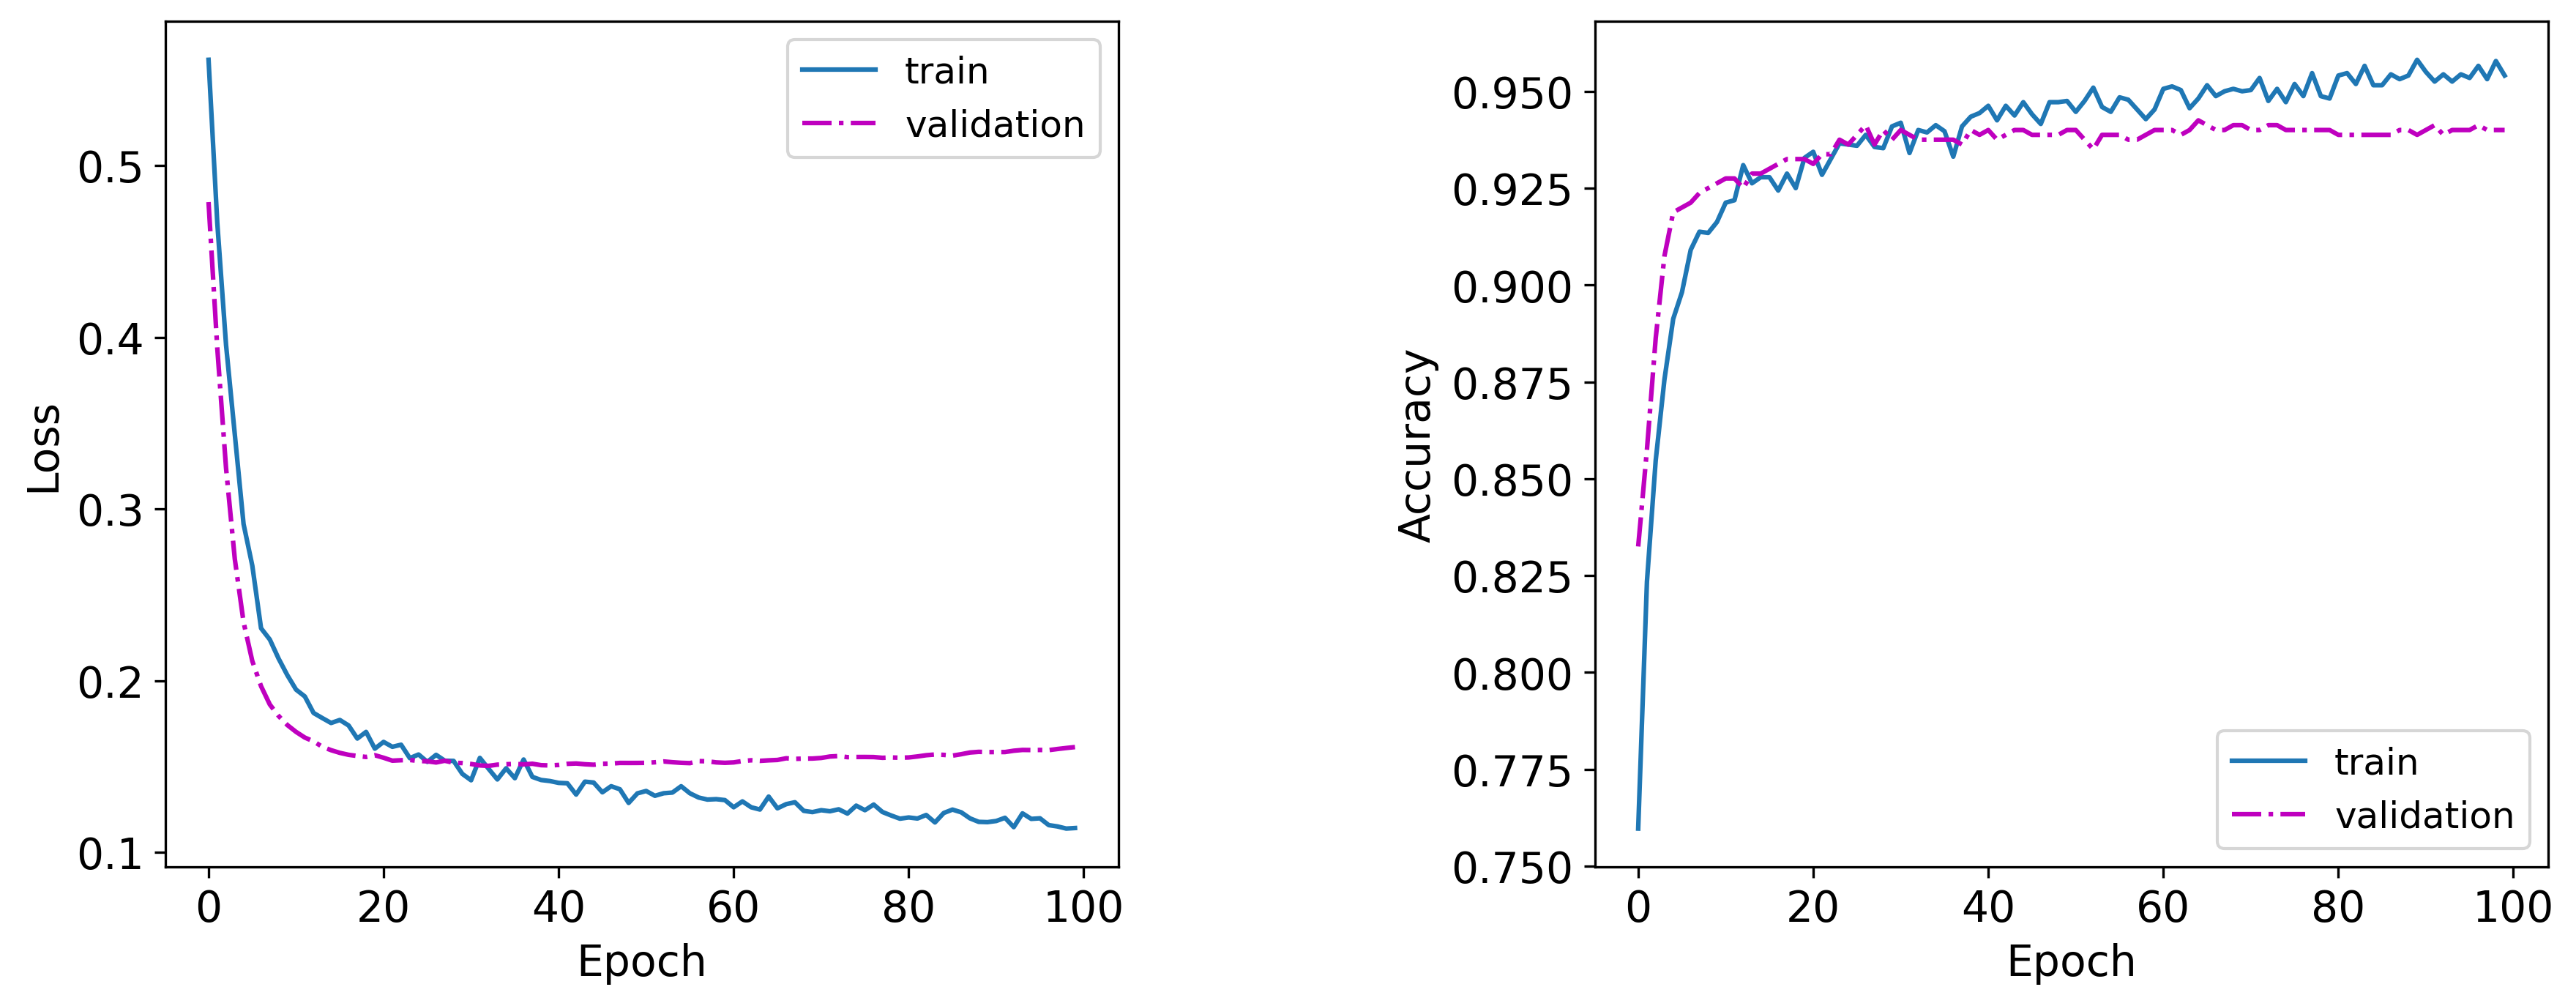

In [46]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_dropout.history['loss'], label = 'train')
plt.plot(mynet_dropout.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_dropout.history['accuracy'], label = 'train')
plt.plot(mynet_dropout.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('RegularizedNN.png', dpi= 300)
#plt.show()

In [ ]:
print(f"Val accuracy (dropout, última época): {mynet_dropout.history['val_accuracy'][-1]:.4f}")
print(f"Val loss (dropout, última época): {mynet_dropout.history['val_loss'][-1]:.4f}")


Val accuracy (dropout, última época): 0.9400
Val loss (dropout, última época): 0.1613


### Early Stopping

In [47]:
from tensorflow.keras.callbacks import EarlyStopping

model_early = Sequential()
model_early.add(Dense(20, activation='relu', input_shape=(24,)))
model_early.add(Dense(20, activation='relu'))
model_early.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_early.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

mynet_early = model_early.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, callbacks=[early_stop], verbose=0)

print(f"Se detuvo en la época: {len(mynet_early.history['loss'])}")

Se detuvo en la época: 29


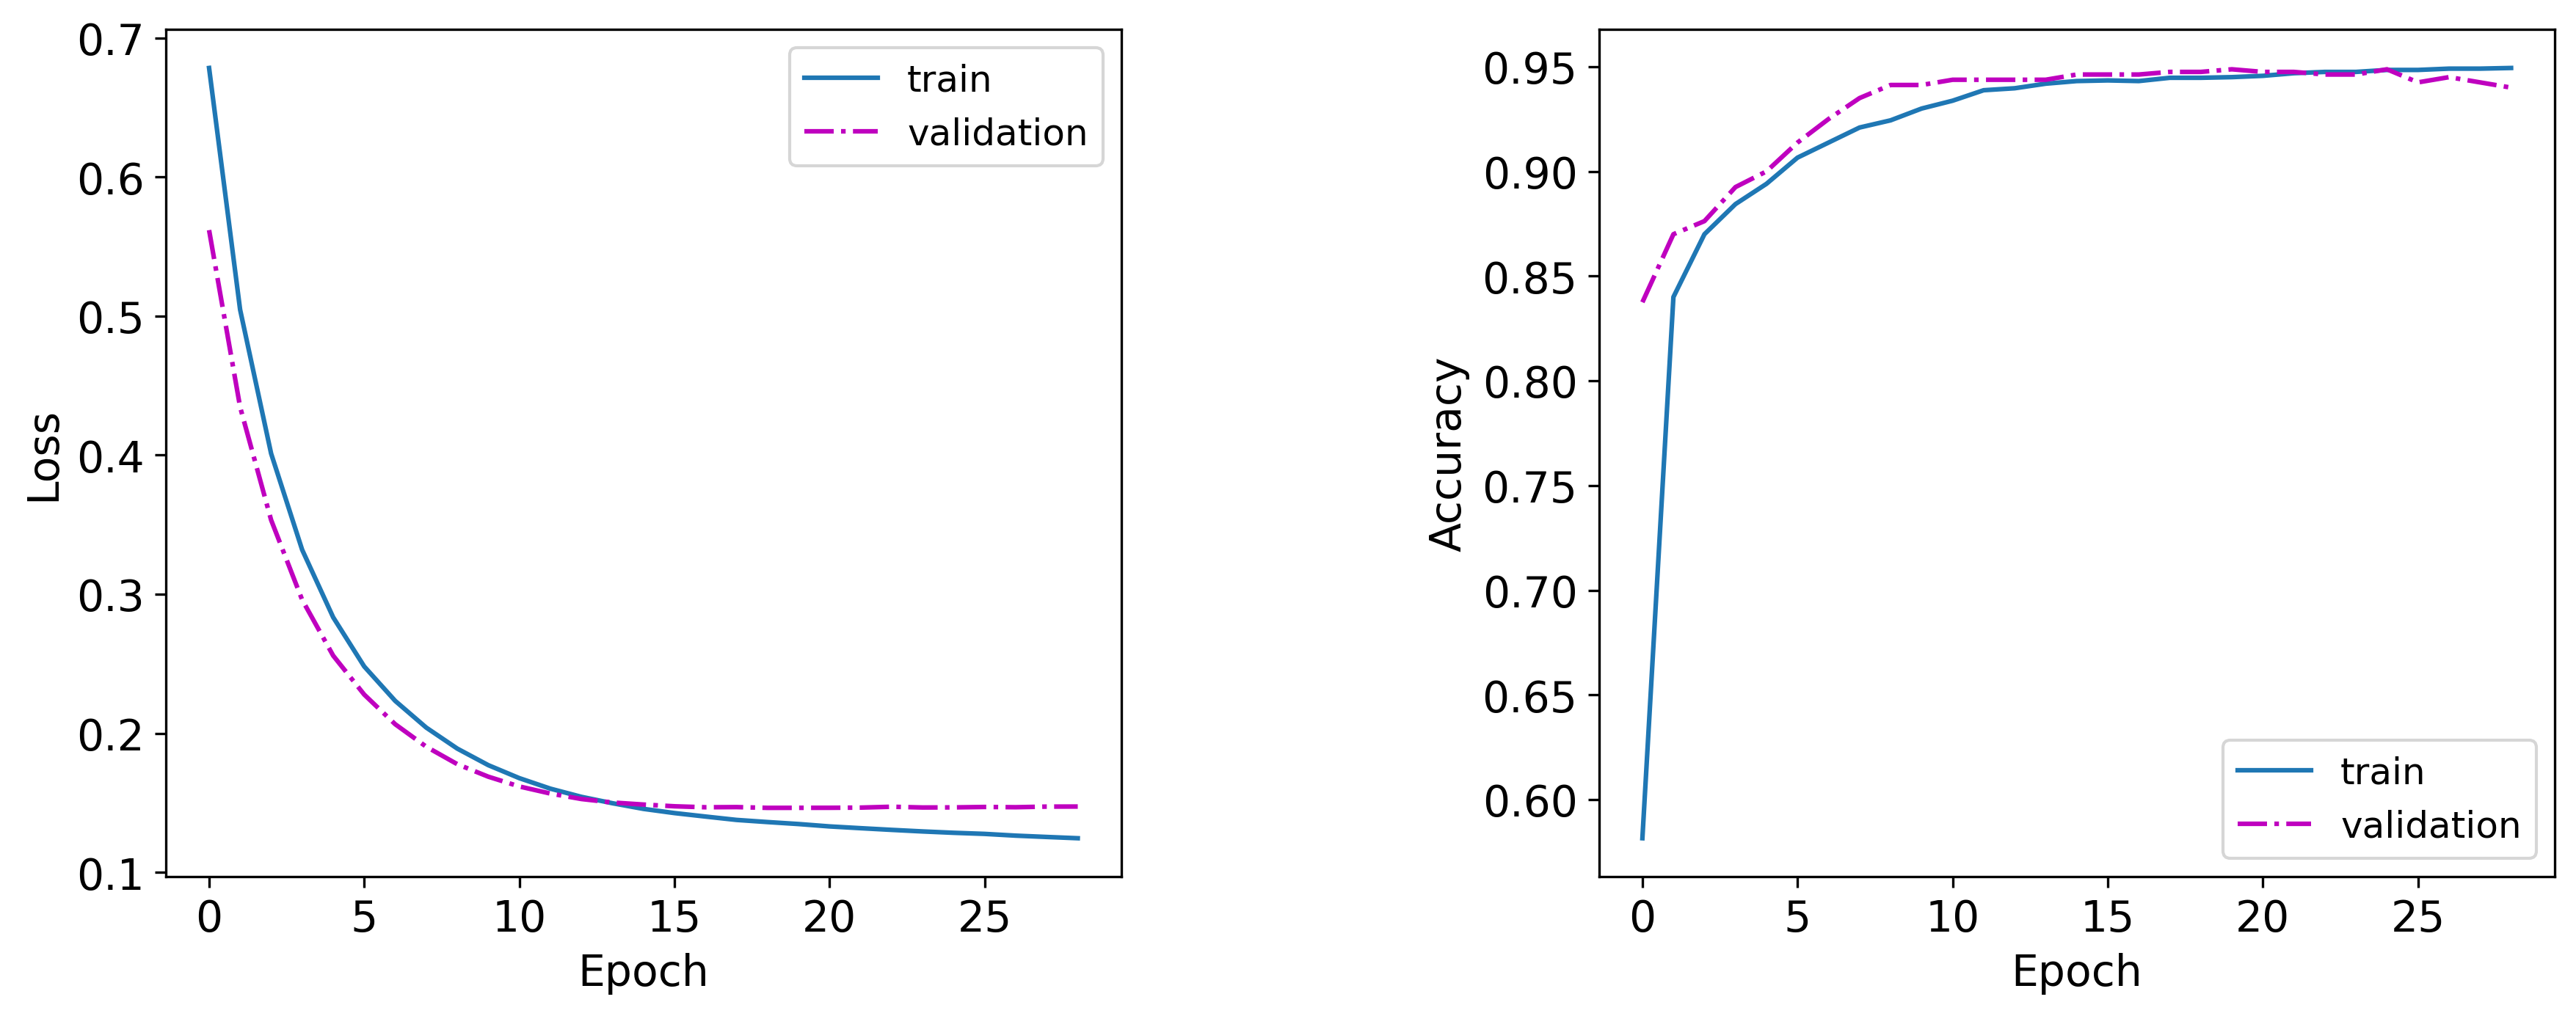

In [48]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_early.history['loss'], label = 'train')
plt.plot(mynet_early.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_early.history['accuracy'], label = 'train')
plt.plot(mynet_early.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('Regularized_Early_NN.png', dpi= 300)
#plt.show()

In [49]:
comparacion = pd.DataFrame([
    {"modelo": "escalado (sin regularizar)",
     "val_acc": mynet_st.history['val_accuracy'][-1],
     "val_loss": mynet_st.history['val_loss'][-1]},
    {"modelo": "escalado + dropout",
     "val_acc": mynet_dropout.history['val_accuracy'][-1],
     "val_loss": mynet_dropout.history['val_loss'][-1]},
    {"modelo": "escalado + early stopping",
     "val_acc": mynet_early.history['val_accuracy'][-1],
     "val_loss": mynet_early.history['val_loss'][-1]},
])
comparacion

,modelo,val_acc,val_loss
0,escalado (sin regularizar),0.93875,0.172972
1,escalado + dropout,0.94000,0.161307
2,escalado + early stopping,0.94000,0.147378


In [50]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

modelos = {
    "sin regularizar": model_st,
    "dropout": model_dropout,
    "early stopping": model_early,
}

for nombre, modelo in modelos.items():
    y_pred_proba = modelo.predict(Xst_test, verbose=0).ravel()
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"=== {nombre} ===")
    print(classification_report(y_test, y_pred, target_names=["ttbar", "4top"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print()

=== sin regularizar ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.85      0.86      0.86       162

    accuracy                           0.95      1000
   macro avg       0.91      0.92      0.92      1000
weighted avg       0.95      0.95      0.95      1000

AUC-ROC: 0.9785
Matriz de confusión:
[[814  24]
 [ 22 140]]

=== dropout ===
              precision    recall  f1-score   support

       ttbar       0.97      0.96      0.97       838
        4top       0.82      0.86      0.84       162

    accuracy                           0.95      1000
   macro avg       0.90      0.91      0.91      1000
weighted avg       0.95      0.95      0.95      1000

AUC-ROC: 0.9804
Matriz de confusión:
[[808  30]
 [ 22 140]]

=== early stopping ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.86      0.85      0.85       16

In [51]:
comparacion = pd.DataFrame([
    {
        "modelo": nombre,
        "val_acc": modelo.evaluate(Xst_val, y_val, verbose=0)[1],
        "test_auc": roc_auc_score(y_test, modelo.predict(Xst_test, verbose=0).ravel()),
        "epocas": len(modelo.history.history['loss']) if hasattr(modelo, 'history') else None,
    }
    for nombre, modelo in modelos.items()
])
comparacion

,modelo,val_acc,test_auc,epocas
0,sin regularizar,0.93875,0.978550,100
1,dropout,0.94000,0.980369,100
2,early stopping,0.94750,0.976259,29


### Después de correr ambas: reflexión

Mire los números reales de dropout y early stopping.

1. Esperaba ese resultado? Explique
2. Dropout actúa *durante* el entrenamiento (apagando neuronas en cada paso). Early stopping actúa *deteniendo* el entrenamiento en un punto. ¿Por qué una de las dos estrategias podría funcionar mejor que la otra en este dataset específico, dado su tamaño y la arquitectura que están usando?
3. ¿Tendría sentido combinar ambas (dropout + early stopping) en vez de elegir una sola? ¿Por qué sí o por qué no?
4. Pruebe distintos valores de dropout y early stopping y discuta cómo cambian los resultados.


**Respuesta:**

1. Parcialmente: early stopping ganó en accuracy (0.9475 vs 0.9400 de dropout) tal como esperaba, pero fue dropout el que dio mejor AUC-ROC en test (0.9804 vs 0.9763). O sea, accuracy y AUC no siempre coinciden en cuál método es "mejor".
2. Dropout regulariza *durante* el entrenamiento agregando ruido, pero igual corre las 100 épocas completas, así que puede seguir sobreajustando un poco hacia el final. Early stopping ataca el problema más directamente: corta justo donde val_loss deja de mejorar (época 29, muy cerca del mínimo real que vimos en el diagnóstico ~época 30), sin necesidad de "adivinar" una tasa de dropout.
3. Sí tiene sentido combinarlos — no son excluyentes. Dropout regulariza la arquitectura y early stopping evita entrenar de más; usarlos juntos es una práctica común y razonable.
4. Con dropout=0.4 se llega a val_acc=0.95 (mejor que 0.2), sugiriendo que este dataset tolera bastante regularización. Con patience más alto o más bajo el resultado cambia poco (0.9425 en ambos casos) — el punto óptimo de parada ya estaba cerca del default (patience=10).

### Optimización de hiperparámetros

Usaremos [`keras_tuner`](https://keras.io/keras_tuner/) para optimizar los hiperparámetros de la arquitectura de la red

### Antes de correr la búsqueda

Con lo que ya sabe del dataset y de los experimentos anteriores, responda:

- ¿Cuántas capas ocultas cree que va a preferir el mejor modelo?
- ¿Dropout va a terminar en 0.0 o en un valor alto?
- ¿El learning rate óptimo va a ser más cercano a 0.0001 o a 0.01?


> **Predicción:** dado que las redes más chicas y simples funcionaron igual o mejor que las grandes en el ejercicio anterior, espero que el mejor modelo tenga pocas capas ocultas (1-2) y un dropout moderado, no 0.0 (ya vimos que dropout alto ayudó). El learning rate óptimo probablemente esté más cerca de 0.001-0.01 que de 0.0001, ya que 0.001 (el default que usamos) ya funcionaba razonablemente bien.

In [52]:
!pip install keras-tuner  #(correr una vez en Colab)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.6 MB/s eta 0:00:00


In [53]:
import keras_tuner as kt

def build_model_tuner(hp):
    model = Sequential()

    #prueba con ndistintos numeros de neuronas, desde 8 a 64, cada 8,
    n_neurons = hp.Int("n_neurons", min_value=8, max_value=64, step=8)
    # activation = hp.Choice("activation", values=["relu", "tanh"])

    #construye la capa con la cantidad de neuronas que fijo en el paso anterior (cada capa con el mismo numero de neuronas)
    model.add(Dense(n_neurons, activation='relu', input_shape=(24,)))

    #numero de capas ocultas (1, 2, o 3)
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=3)
    for i in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))

    #tasa de dropout (0.1-0.5, en pasos de 0.1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    #la capa de salida queda fija, para la clasificacion binaria
    model.add(Dense(1, activation='sigmoid'))

    #tasa de aprendizaje, entre 0.0001 y 0.01
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

#prueba solo combinaciones aleatorias para reducir costo computacional
tuner = kt.RandomSearch(
    build_model_tuner,
    objective="val_accuracy",
    max_trials=15,          # número de combinaciones a probar
    executions_per_trial=1,
    directory="tuner_resultados",
    project_name="particle_id",
)

tuner.search(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=30,
    batch_size=200,
    verbose=1,
)

Trial 15 Complete [00h 00m 08s]
val_accuracy: 0.9087499976158142

Best val_accuracy So Far: 0.949999988079071
Total elapsed time: 00h 02m 30s


In [54]:
# Mejor modelo encontrado
mejores_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros:")
for param in mejores_hp.values:
    print(f"  {param}: {mejores_hp.values[param]}")



Mejores hiperparámetros:
  n_neurons: 32
  n_hidden: 1
  dropout_rate: 0.2
  learning_rate: 0.003160297866362307


### Evaluamos finalmente el modelo con el set de prueba, que sólo se usa en el paso final

In [55]:
mejor_modelo = tuner.get_best_models(1)[0]
scores = mejor_modelo.evaluate(Xst_test, y_test, verbose=0)
print(f"\nAccuracy en test: {scores[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Accuracy en test: 0.9460


In [56]:
# Resumen de los mejores trials
tuner.results_summary(num_trials=5)

Results summary
Results in tuner_resultados/particle_id
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 09 summary
Hyperparameters:
n_neurons: 32
n_hidden: 1
dropout_rate: 0.2
learning_rate: 0.003160297866362307
Score: 0.949999988079071

Trial 10 summary
Hyperparameters:
n_neurons: 48
n_hidden: 3
dropout_rate: 0.4
learning_rate: 0.004415184009521187
Score: 0.949999988079071

Trial 11 summary
Hyperparameters:
n_neurons: 56
n_hidden: 2
dropout_rate: 0.0
learning_rate: 0.0012500670287418348
Score: 0.9487500190734863

Trial 07 summary
Hyperparameters:
n_neurons: 32
n_hidden: 2
dropout_rate: 0.2
learning_rate: 0.0007277950249321667
Score: 0.9474999904632568

Trial 04 summary
Hyperparameters:
n_neurons: 16
n_hidden: 3
dropout_rate: 0.1
learning_rate: 0.006086096327976817
Score: 0.9462500214576721


### Mire los 5 mejores trials, no solo el ganador


1. ¿Hay algún empate o casi-empate en el score entre dos trials? Compare sus arquitecturas (n_neurons, n_hidden) y su dropout_rate uno al lado del otro, ¿qué tan distintos son entre sí?

2. Si encuentra un caso así, ¿qué le dice eso sobre la relación entre tamaño de red y necesidad de regularización? ¿es dropout algo que "siempre ayuda", o depende de si la arquitectura ya es lo suficientemente chica como para no necesitarlo?

3. Si tuviera que elegir entre dos modelos con score casi igual pero muy distintos en complejidad, ¿cuál elige para poner en producción y por qué? (piense en costo de cómputo, riesgo de overfitting futuro, interpretabilidad)

4. Compare el mejor modelo de la búsqueda automática contra su mejor intento manual (dropout o early stopping). ¿Vale la pena el costo computacional de la búsqueda para esa diferencia?



In [ ]:
# Comparamos los dos mejores trials, que quedaron prácticamente empatados
import pandas as pd

top_trials = pd.DataFrame([
    {"trial": "09", "n_neurons": 32, "n_hidden": 1, "dropout": 0.2, "lr": 0.003160, "score": 0.949999988},
    {"trial": "10", "n_neurons": 48, "n_hidden": 3, "dropout": 0.4, "lr": 0.004415, "score": 0.949999988},
])
top_trials


  trial  n_neurons  n_hidden  dropout        lr        score
0    09         32         1      0.2  0.003160  0.949999988
1    10         48         3      0.4  0.004415  0.949999988

**Respuesta:**

1. Sí, hay un empate casi exacto entre el trial 09 y el trial 10 (ambos con score ≈ 0.9500). Sus arquitecturas son muy distintas: el trial 09 es chico (32 neuronas, **1** capa oculta, dropout 0.2) y el trial 10 es bastante más grande (48 neuronas, **3** capas ocultas, dropout 0.4).
2. Esto sugiere que dropout no "siempre ayuda" en una cantidad fija: la red grande necesitó un dropout más alto (0.4) para llegar al mismo desempeño que la red chica con dropout moderado (0.2). Es decir, la necesidad de regularización escala con la capacidad del modelo, no es un valor universal.
3. Elegiría el modelo del trial 09 (más chico): mismo score, pero muchos menos parámetros → menor costo de cómputo, menor riesgo de sobreajuste si cambia la distribución de datos en producción, y arquitectura más fácil de interpretar/depurar.
4. El mejor modelo de la búsqueda (val_accuracy 0.9500, test accuracy 0.9460) es similar al mejor intento manual (early stopping, val_accuracy 0.9475). La ganancia es pequeña (~0.2-0.5 puntos), y costó 15 trials de entrenamiento. Para este dataset, probablemente no vale la pena tanto cómputo — el ajuste manual con early stopping ya captura casi todo el beneficio.

### Reflexión final

1. A lo largo de este notebook probó varios modelos: sin escalar, escalado, con dropout, con early stopping, y el resultado de la búsqueda automática de hiperparámetros. ¿Cuál de todos eligiría como el modelo final, y por qué? Use números concretos de sus tablas, no solo accuracy.

2. El SVM del notebook anterior llegó a 94-95%. ¿Su mejor red neuronal lo superó? Si la diferencia es chica, ¿vale la pena toda la complejidad extra (arquitectura, regularización, búsqueda de hiperparámetros) por esa ganancia?

3. Comparen el salto de accuracy entre "sin escalar → escalado" contra el salto entre "escalado sin regularizar → mejor modelo de la búsqueda de hiperparámetros". ¿Cuál salto fue más grande? ¿Qué les dice eso sobre dónde conviene invertir tiempo primero cuando entrenan una red nueva?

**Respuesta:**

1. Me quedaría con el modelo escalado + dropout (0.2): val_accuracy=0.9400, test AUC-ROC=0.9804 (el más alto de todos los modelos manuales) y test accuracy=0.95. Es apenas más lento de entrenar que early stopping pero generaliza mejor según AUC, y usa una arquitectura simple sin necesitar la búsqueda automática completa.
2. Sí, por poco: SVM llegó a 94-95%, y la mejor red (dropout, AUC 0.9804, accuracy≈0.95) queda en ese mismo rango o apenas por encima. La diferencia es chica, así que probablemente no vale la pena toda la complejidad extra (búsqueda de hiperparámetros con 15 trials) solo por esa ganancia marginal — el escalado + un poco de regularización ya alcanza el nivel del SVM.
3. El salto más grande fue "sin escalar → escalado": pasamos de un accuracy inestable (~0.76, oscilando) a ~0.94 estable, un salto de casi 20 puntos. El salto "escalado sin regularizar (0.9388) → mejor modelo de la búsqueda (0.9500)" fue de apenas ~1 punto. Conclusión: cuando se entrena una red nueva, conviene invertir tiempo primero en el preprocesamiento de datos (escalado) antes que en búsquedas costosas de hiperparámetros — el retorno es mucho mayor.